## Initial Processing / Helper Functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# load data 
df = pd.read_csv("data/all_participants_summary.csv")
df.head()

,participant,task,input_mode,label,duration,modifier
0,V1,1,standard_input,task_1a,0.982,NaN
1,V1,1,voice_control,task_1b,17.858,NaN
2,V1,1,plugin,task_1c,3.554,NaN
3,V1,2,standard_input,task_2a,1.566,NaN
4,V1,2,voice_control,task_2b,28.003,NaN


In [2]:
TASK_NAME_MAP = {
    1: "Selecting object",
    2: "Zooming to object",
    3: "Alignment positioning",
    4: "Freehand resizing one edge",
    5: "Freehand resizing two edges",
}

INPUT_MODE_DISPLAY = {
    "standard_input": "standard",
    "plugin": "plugin",
    "voice_control": "voice control",
}

# map tasks to a new task_name column - easier to interpret
df["task_name"] = df["task"].map(TASK_NAME_MAP)

# map input mode to plaintext version
df["input_type"] = df["input_mode"].map(INPUT_MODE_DISPLAY)

# fixed row/column order so every table below displays consistently
ROW_ORDER = list(TASK_NAME_MAP.values())
COLUMN_ORDER = ["standard", "plugin", "voice control"]

df.head()

,participant,task,input_mode,label,duration,modifier,task_name,input_type
0,V1,1,standard_input,task_1a,0.982,NaN,Selecting object,standard
1,V1,1,voice_control,task_1b,17.858,NaN,Selecting object,voice control
2,V1,1,plugin,task_1c,3.554,NaN,Selecting object,plugin
3,V1,2,standard_input,task_2a,1.566,NaN,Zooming to object,standard
4,V1,2,voice_control,task_2b,28.003,NaN,Zooming to object,voice control


In [3]:
# set up code for making a pivot table which is easier to visualise
def make_pivot(data, aggfunc):
    pivot = data.pivot_table(
        index="task_name",
        columns="input_type",
        values="duration",
        aggfunc=aggfunc,
    )
    return pivot.reindex(index=ROW_ORDER, columns=COLUMN_ORDER).round(2)

## Descriptive Statistics

In [4]:
mean_table = make_pivot(df, "mean")
print("Mean duration (s)")
mean_table

Mean duration (s)


input_type,standard,plugin,voice control
task_name,,,
Selecting object,0.89,4.82,14.18
Zooming to object,1.97,4.99,48.59
Alignment positioning,3.11,5.59,53.20
Freehand resizing one edge,4.37,33.67,66.92
Freehand resizing two edges,3.43,73.15,50.14


In [5]:
def fastest_quartile_mean(group):
    threshold = group.quantile(0.25) #finds value at 25th percentile
    fastest = group[group <= threshold] #filters for only fastest attempts
    return fastest.mean()

quartile_series = df.groupby(["task_name", "input_type"])["duration"].apply(fastest_quartile_mean)

quartile_table = quartile_series.unstack("input_type").reindex(index=ROW_ORDER, columns=COLUMN_ORDER).round(2)
print("Fastest-quartile mean duration (s)")
quartile_table

Fastest-quartile mean duration (s)


input_type,standard,plugin,voice control
task_name,,,
Selecting object,0.70,3.03,11.33
Zooming to object,0.96,2.92,24.29
Alignment positioning,2.18,3.96,23.97
Freehand resizing one edge,3.19,8.50,44.53
Freehand resizing two edges,2.87,31.02,40.28


In [6]:
best_table = make_pivot(df, "min")
print("Best individual duration (s)")
best_table

Best individual duration (s)


input_type,standard,plugin,voice control
task_name,,,
Selecting object,0.61,2.12,11.11
Zooming to object,0.63,1.97,17.41
Alignment positioning,1.92,2.75,17.85
Freehand resizing one edge,2.83,5.88,34.41
Freehand resizing two edges,2.66,22.33,37.50


## Box Plots

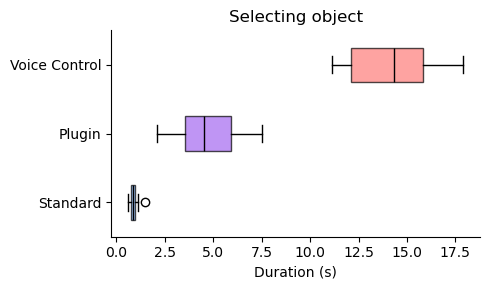

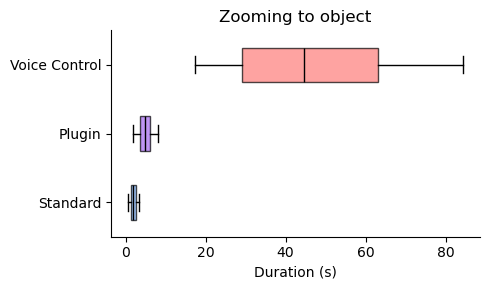

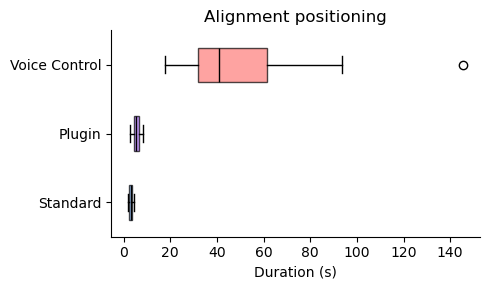

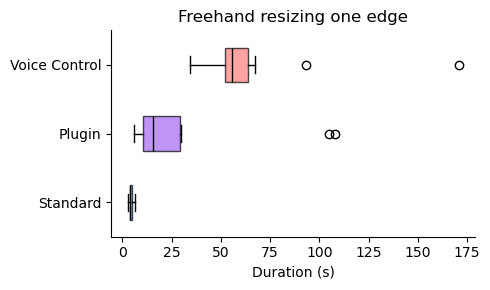

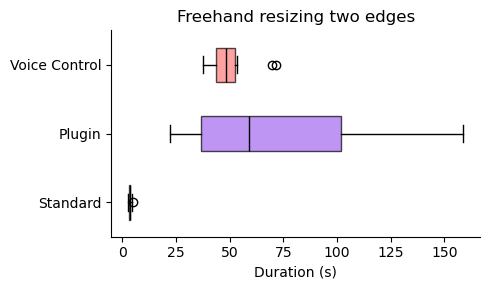

In [ ]:
XTICK_LABELS = {
    "standard": "Standard",
    "plugin": "Plugin",
    "voice control": "Voice Control",
}

BOX_COLORS = {
    "standard": "#6FA3E9",
    "plugin": "#A568F0",
    "voice control": "#FE7D79",
}

for task_num, task_label in TASK_NAME_MAP.items():
    task_df = df[df["task"] == task_num]
    data = [task_df.loc[task_df["input_type"] == mode, "duration"].values for mode in COLUMN_ORDER]

    fig, ax = plt.subplots(figsize=(5, 3))
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, vert=False)

    for patch, mode in zip(bp["boxes"], COLUMN_ORDER):
        patch.set_facecolor(BOX_COLORS[mode])
        patch.set_alpha(0.7)
    for median in bp["medians"]:
        median.set_color("black")

    ax.set_yticklabels([XTICK_LABELS[mode] for mode in COLUMN_ORDER])
    ax.set_xlabel("Duration (s)")
    ax.set_title(task_label)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()